# Frozen Lake – Proceso de Decisión de Markov (MDP)

En este notebook vamos a resolver el famoso entorno **Frozen Lake**, donde un agente debe cruzar un lago congelado desde el inicio hasta la meta.

El problema principal reside en que **el hielo es resbaladizo**: si el agente intenta moverse en una dirección, puede terminar desviándose a una dirección perpendicular con cierta probabilidad.

---

## Descripción del Entorno

El entorno es un **grid de 4×4** con las siguientes celdas:

| Símbolo | Significado | Recompensa |
|---------|-------------|------------|
| **S** | Start – posición inicial del agente | 0 |
| **F** | Frozen – camino seguro de hielo | 0 |
| **H** | Hole – agujero en el hielo (fin del juego) | 0 |
| **G** | Goal – meta del agente (fin del juego) | **+1** |

### Dinámica Estocástica

Al tomar una acción, el agente **no siempre se mueve a donde quiere**:

- **1/3 de probabilidad** → se mueve en la dirección deseada.
- **1/3 de probabilidad** → se desvía a uno de los lados perpendiculares.
- **1/3 de probabilidad** → se desvía al otro lado perpendicular.

Por ejemplo, si el agente elige ir al **Norte**, puede terminar yendo al Norte, al Este o al Oeste, cada uno con probabilidad 1/3.

---

## Representación del Grid

El lago se representa con una matriz 4×4:

```
S  F  F  F
F  H  F  H
F  F  F  H
H  F  F  G
```


In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

frozen_lake_grid = np.array([
    ['S', 'F', 'F', 'F'],
    ['F', 'H', 'F', 'H'],
    ['F', 'F', 'F', 'H'],
    ['H', 'F', 'F', 'G']
])

print(frozen_lake_grid)

[['S' 'F' 'F' 'F']
 ['F' 'H' 'F' 'H']
 ['F' 'F' 'F' 'H']
 ['H' 'F' 'F' 'G']]


---

## Task 2.1 – Modelado del MDP

Para modelar el problema como un **Proceso de Decisión de Markov (MDP)**, necesitamos definir cuatro componentes clave:

1. **Estados** S: Los 16 estados posibles 0 - 15, numerados de izquierda a derecha y de arriba a abajo en el grid.
2. **Acciones** A: Cuatro acciones posibles → Norte (`N`), Este (`E`), Oeste (`W`), Sur (`S`).
3. **Función de Transición** T(s, a, s'): Probabilidad de llegar al estado $s'$ al tomar la acción $a$ desde el estado $s$. Captura la **estocasticidad** del hielo (1/3 por cada dirección posible).
4. **Función de Recompensa** R(s, a, s'): Recompensa obtenida al transitar de $s$ a $s'$ tomando la acción $a$. Solo es $+1$ si $s'$ es la meta (**G**); en cualquier otro caso es $0$.

### Funciones auxiliares

Antes de construir las matrices, definimos tres funciones auxiliares:

- `get_coord(state)` → Convierte un estado (0–15) a coordenadas `(fila, columna)`.
- `get_state(row, col)` → Convierte coordenadas `(fila, columna)` a estado (0–15).
- `try_move(row, col, direction_id)` → Calcula la nueva posición tras intentar moverse en una dirección, **respetando los límites del grid** (si choca con una pared, se queda en el mismo lugar).

### Diccionario de direcciones estocásticas

El diccionario `stochastic_directions` mapea cada acción a las **tres direcciones posibles** en las que el agente puede terminar:

| Acción | Dirección deseada | Desvíos posibles |
|--------|------------------|-----------------|
| Norte (0) | Norte | Este, Oeste |
| Este (1) | Este | Norte, Sur |
| Sur (2) | Sur | Este, Oeste |
| Oeste (3) | Oeste | Norte, Sur |


In [2]:
n_states = 16
n_actions = 4

actions = ['N','E','W','S']

#Estados posibles en los que se peude estar (estado, accion, estado resultante)
T = np.zeros((n_states, n_actions, n_states)) #Transicion
R = np.zeros((n_states, n_actions, n_states)) #Recompensa

def get_coord(state):
    return state//4, state%4

def get_state(row, col):
    return row * 4 + col

def try_move(row, col, direction_id):
    if direction_id == 0: row = max(0, row - 1)    # Norte
    elif direction_id == 1: col = min(3, col + 1)  # Este
    elif direction_id == 2: row = min(3, row + 1)  # Sur
    elif direction_id == 3: col = max(0, col - 1)  # Oeste
    return row, col


stochastic_directions = {
    0: [0, 1, 3], # Norte (podemos ir al norte o resbalar a los lados)
    1: [1, 0, 2], # Este (podemos ir al este o resbalar a los lados)
    2: [2, 1, 3], # Sur (podemos ir al sur o resbalar a los lados)
    3: [3, 0, 2]  # Oeste (podemos ir al oeste o resbalar a los lados)
}


---

### Construcción de las Matrices $T$ y $R$

Con los componentes anteriores ya definidos, ahora llenamos las matrices de transición $T$ y recompensa $R$ recorriendo todos los estados y acciones posibles.

**Lógica del algoritmo:**

1. **Estados terminales** (`H` o `G`): El agente queda atrapado. La probabilidad de quedarse en el mismo estado es $1$ y la recompensa es $0$. Estos estados se tratan por separado y se omite el resto del procesamiento con `continue`.

2. **Estados normales** (`S` o `F`): Para cada acción $a$, consultamos las tres direcciones posibles del diccionario `stochastic_directions`. Por cada dirección:
   - Calculamos el estado de destino $s'$ usando `try_move`.
   - **Sumamos** $\frac{1}{3}$ a T[s, a, s']. Se usa `+=` porque si dos direcciones distintas llevan al mismo $s'$ como chocar a una pared, sus probabilidades se acumulan correctamente.
   - Si el estado destino es la meta `G`, asignamos R[s, a, s'] = 1.0; en caso contrario, R[s, a, s'] = 0.0.


In [ ]:
for s in range(n_states):
    row, col = get_coord(s)
    cell_type = frozen_lake_grid[row, col]
    
    # ESTADOS TERMINALES: Si caemos en 'H' (Agujero) o 'G' (Meta), el juego termina.
    # El agente queda atrapado ahí. Probabilidad 1 de quedarse, recompensa 0.
    if cell_type == 'H' or cell_type == 'G':
        for a in range(n_actions):
            T[s, a, s] = 1.0
            R[s, a, s] = 0.0
        continue
        
    # ESTADOS NORMALES: 'S' o 'F'
    for a in range(n_actions):
        # Obtenemos hacia dónde podría ir realmente (1/3 intencionado, 2/3 resbalones)
        possible_moves = stochastic_directions[a]
        
        for move_dir in possible_moves:
            next_row, next_col = try_move(row, col, move_dir)
            s_prime = get_state(next_row, next_col)
            next_cell_type = frozen_lake_grid[next_row, next_col]
            
            # Sumamos 1/3 a la probabilidad de terminar en ese estado (s_prime).
            # las probabilidades de quedarse en el mismo lugar se acumulan correctamente.
            T[s, a, s_prime] += 1/3
            
            # Asignamos recompensa solo si el estado siguiente es la Meta ('G').
            if next_cell_type == 'G':
                R[s, a, s_prime] = 1.0
            else:
                R[s, a, s_prime] = 0.0

print("¡Matrices T y R construidas con éxito!")


¡Matrices T y R construidas con éxito!


## Task 2.2 – Algoritmo de Iteración de Valores (Value Iteration)

El objetivo de **Value Iteration** es encontrar la **función de valor óptima** $V^*(s)$, es decir, el valor acumulado máximo que un agente puede esperar obtener desde cada estado, siguiendo la política más inteligente posible.

Una vez que conocemos $V^*$, podemos derivar directamente la **política óptima** $\pi^*(s)$ — qué acción tomar en cada estado.

---

### 1. Inicialización

```python
gamma   = 0.9
epsilon = 1e-6
V = np.zeros(n_states)   # V_0(s) = 0 para todo s
```

| Parámetro | Valor | Significado |
|-----------|-------|-------------|
| `gamma` γ | 0.9 | Factor de descuento: las recompensas futuras valen un 10 % menos por cada paso |
| `epsilon` ε | 1e-6 | Umbral de convergencia: cuando el cambio máximo en V sea menor a esto, paramos |
| `V` | vector de 16 ceros | Estimación inicial: asumimos que todos los estados valen 0 |

El factor de descuento γ < 1 cumple dos funciones: garantiza que el algoritmo converge y modela la preferencia del agente por recompensas inmediatas sobre recompensas lejanas.


In [15]:
gamma = 0.9
epsilon = 1e-6 # Margen de error muy pequeño para la convergencia
V = np.zeros(n_states) # Vector V_0(s) = 0

### 2. Bucle Principal — Ecuación de Bellman

En cada iteración calculamos el nuevo valor de cada estado aplicando la Ecuación de Bellman y repetimos hasta que la diferencia máxima entre $V_k$ y $V_{k+1}$ sea menor a $\epsilon$.

$$V_{k+1}(s) = \max_{a \in A} \sum_{s'} T(s, a, s') \left[ R(s, a, s') + \gamma \cdot V_k(s') \right]$$

Donde:
- $T(s, a, s')$ es la probabilidad de llegar a $s'$ tomando la acción $a$ desde $s$.
- $R(s, a, s')$ es la recompensa inmediata de esa transición.
- $\gamma \cdot V_k(s')$ es el valor descontado del estado siguiente.

In [16]:
iteration = 0
while True:
    delta = 0
    V_new = np.zeros(n_states)
    
    for s in range(n_states):
        row, col = get_coord(s)
        
        # Los estados terminales no tienen valor futuro
        if frozen_lake_grid[row, col] in ['H', 'G']:
            V_new[s] = 0.0
            continue
            
        # Calculamos el valor esperado para cada acción
        action_values = np.zeros(n_actions)
        for a in range(n_actions):
            for s_prime in range(n_states):
                prob = T[s, a, s_prime]
                if prob > 0: # Solo calculamos si hay probabilidad de llegar
                    reward = R[s, a, s_prime]
                    # Ecuación de Bellman
                    action_values[a] += prob * (reward + gamma * V[s_prime])
        
        # El nuevo valor del estado es el máximo valor esperado de las acciones
        V_new[s] = np.max(action_values)
        
        # Calculamos la diferencia máxima para verificar la convergencia
        delta = max(delta, abs(V_new[s] - V[s]))
        
    V = V_new.copy()
    iteration += 1
    
    # Condición de parada
    if delta < epsilon:
        print(f"¡Convergencia alcanzada en la iteración {iteration}!")
        break

¡Convergencia alcanzada en la iteración 78!


### 3. Extracción de Política

Con $V^*$ convergido, calculamos la política óptima $\pi^*(s)$ seleccionando para cada estado la acción que maximiza el valor esperado (`argmax`).


In [17]:
policy = np.zeros(n_states, dtype=int)
for s in range(n_states):
    row, col = get_coord(s)
    if frozen_lake_grid[row, col] in ['H', 'G']:
        continue
        
    action_values = np.zeros(n_actions)
    for a in range(n_actions):
        for s_prime in range(n_states):
            prob = T[s, a, s_prime]
            if prob > 0:
                reward = R[s, a, s_prime]
                action_values[a] += prob * (reward + gamma * V[s_prime])
                
    # Extraemos la acción que nos dio el valor máximo (argmax)
    policy[s] = np.argmax(action_values)

### 4. Visualización — Mapa de Calor y Política Óptima

Graficamos los valores $V^*(s)$ como un mapa de calor 4×4 y mostramos la acción óptima de cada celda con una flecha. Las celdas más azules son las más valiosas (más fácil llegar a la meta desde ellas).

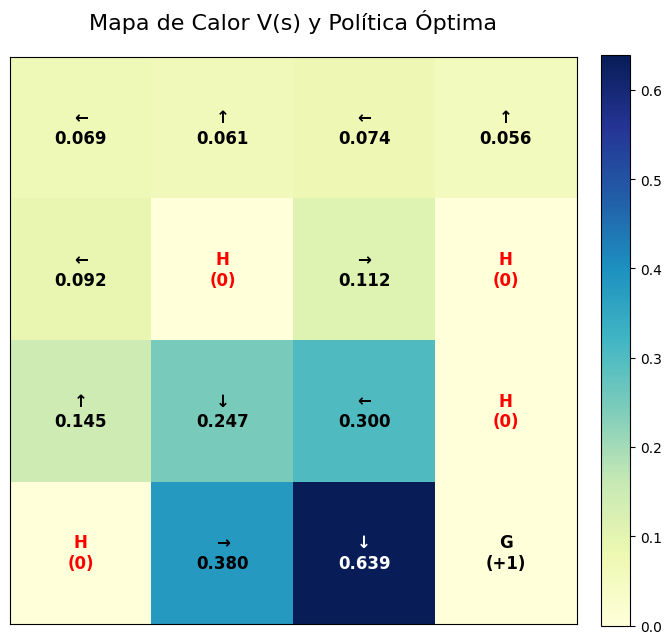

In [18]:
arrows = {0: '↑', 1: '→', 2: '↓', 3: '←'}
V_grid = V.reshape((4, 4))

fig, ax = plt.subplots(figsize=(8, 8))
cax = ax.matshow(V_grid, cmap='YlGnBu')
fig.colorbar(cax, fraction=0.046, pad=0.04)

for i in range(4):
    for j in range(4):
        s = get_state(i, j)
        cell_type = frozen_lake_grid[i, j]
        
        if cell_type == 'G':
            text = "G\n(+1)"
        elif cell_type == 'H':
            text = "H\n(0)"
        else:
            arrow = arrows[policy[s]]
            val = V_grid[i, j]
            text = f"{arrow}\n{val:.3f}"
            
        text_color = "white" if V_grid[i, j] > 0.5 else "black"
        if cell_type == 'H': text_color = "red"
        
        ax.text(j, i, text, va='center', ha='center', color=text_color, fontsize=12, fontweight='bold')

plt.title("Mapa de Calor V(s) y Política Óptima", fontsize=16, pad=20)
plt.xticks([])
plt.yticks([])
plt.show()